In [289]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [290]:
df_train = pd.read_csv('/content/train.csv')
display(df_train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [291]:
df_train.shape

(891, 12)

In [292]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [293]:
df_train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [294]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [295]:
df_train.duplicated().sum()

np.int64(0)

In [296]:
df_train["Age"].fillna(df_train["Age"].median(), inplace=True)

In [297]:
df_train["Cabin"].isnull().sum()

np.int64(687)

In [298]:
df_train.drop("Cabin", axis=1, inplace=True)

In [299]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [300]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [301]:
correlation = df_train.corr(numeric_only=True)
correlation

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


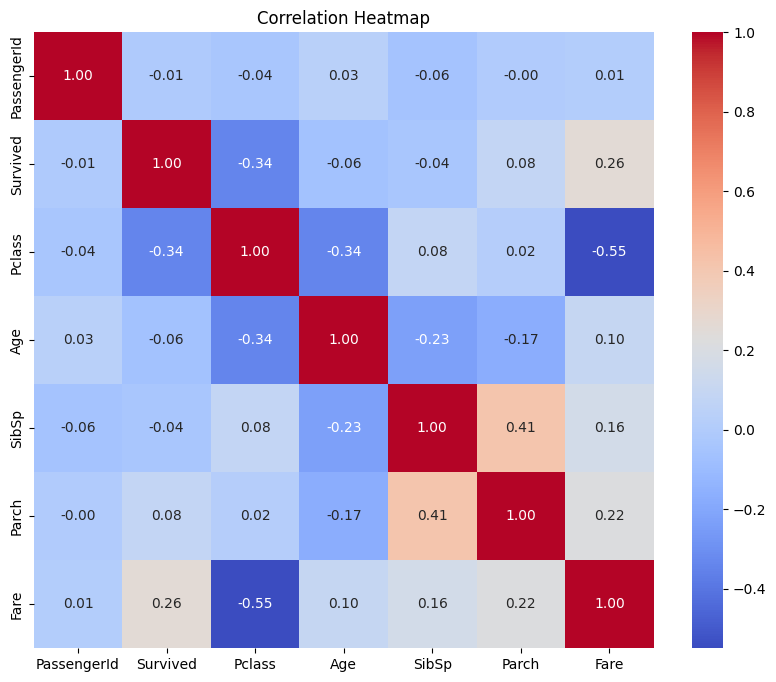

In [302]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [303]:
correlation["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.064910
Pclass,-0.338481


In [304]:
df_train.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [305]:
from sklearn.ensemble import RandomForestClassifier

In [306]:
X = df_train.drop("Survived", axis=1)
y = df_train["Survived"]

In [307]:
df_train.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


In [308]:
df_train["Sex"] = df_train["Sex"].map({
    "male": 0,
    "female": 1
})

In [309]:
df_train["Sex"].head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [310]:
df_train["Embarked"] = df_train["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [311]:
X = df_train.drop("Survived", axis=1)
y = df_train["Survived"]

In [312]:
X.dtypes

,0
Pclass,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,float64


In [313]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [314]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance

,Feature,Importance
0,Pclass,0.088849
1,Sex,0.261690
2,Age,0.260261
3,SibSp,0.046027
4,Parch,0.039797
5,Fare,0.270212
6,Embarked,0.033165


In [315]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Fare,0.270212
1,Sex,0.261690
2,Age,0.260261
0,Pclass,0.088849
3,SibSp,0.046027
4,Parch,0.039797
6,Embarked,0.033165


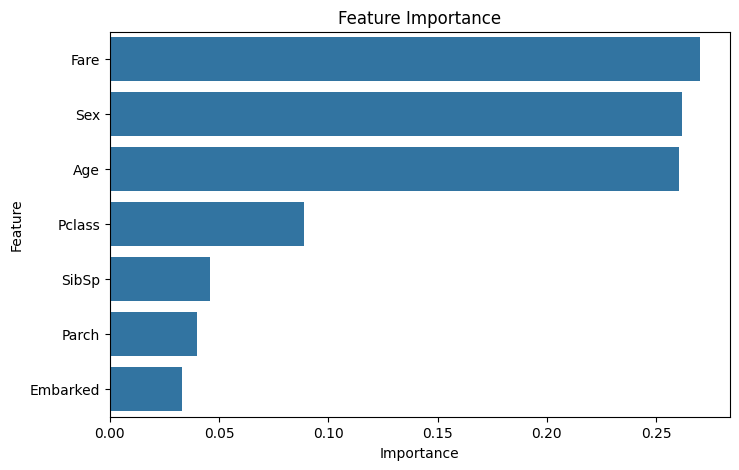

In [316]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [317]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [318]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [319]:
df_train.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [320]:
df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])

In [321]:
df_train.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [322]:
X = df_train.drop("Survived", axis=1)
y = df_train["Survived"]

### Sanity Check: Verify `X` DataFrame before Model Training

Before refitting the Logistic Regression model, I will explicitly display the data types and the first few rows of `X` to confirm that all columns are numeric and that no unexpected string values are present. This helps ensure `X` is in the correct format for training.

In [323]:
print(X.dtypes)
display(X.head())

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked    float64
dtype: object


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0.0
1,1,1,38.0,1,0,71.2833,1.0
2,3,1,26.0,0,0,7.9250,0.0
3,1,1,35.0,1,0,53.1000,0.0
4,3,0,35.0,0,0,8.0500,0.0


### Retraining Logistic Regression Model

Now that we have verified `X` contains only numeric features, I will proceed to re-train the Logistic Regression model.

In [324]:
lr = LogisticRegression(random_state=42)
lr.fit(X, y)


LogisticRegression(random_state=42)

### Train KNeighborsClassifier Model

Now, I'll train the third model, a KNeighborsClassifier, using the prepared `X` and `y` datasets.

In [325]:
knn = KNeighborsClassifier()
knn.fit(X, y)

KNeighborsClassifier()

### Evaluate KNeighborsClassifier Model

Now, I will evaluate the trained KNeighborsClassifier model using accuracy, precision, recall, and F1-score. To do so, I will first split the data into training and test sets.

In [326]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn_predictions = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print(f"KNN Accuracy: {knn_accuracy:.4f}")
print(f"KNN Precision: {knn_precision:.4f}")
print(f"KNN Recall: {knn_recall:.4f}")
print(f"KNN F1-Score: {knn_f1:.4f}")

KNN Accuracy: 0.8212
KNN Precision: 0.8621
KNN Recall: 0.6757
KNN F1-Score: 0.7576


### Evaluate Logistic Regression Model

Now, I will evaluate the trained Logistic Regression model using accuracy, precision, recall, and F1-score with the previously split test data.

In [327]:
lr_predictions = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")
print(f"Logistic Regression Recall: {lr_recall:.4f}")
print(f"Logistic Regression F1-Score: {lr_f1:.4f}")

Logistic Regression Accuracy: 0.8101
Logistic Regression Precision: 0.7778
Logistic Regression Recall: 0.7568
Logistic Regression F1-Score: 0.7671


### Evaluate Random Forest Classifier Model

Finally, I will evaluate the trained Random Forest Classifier model using accuracy, precision, recall, and F1-score with the previously split test data.

In [328]:
rf_predictions = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1-Score: {rf_f1:.4f}")

Random Forest Accuracy: 0.9944
Random Forest Precision: 1.0000
Random Forest Recall: 0.9865
Random Forest F1-Score: 0.9932


### Compare All Models

I will now create a DataFrame to compare the accuracy, precision, recall, and F1-score for the KNeighborsClassifier, Logistic Regression, and Random Forest Classifier models.

In [329]:
model_comparison = pd.DataFrame({
    'Model': ['KNeighborsClassifier', 'Logistic Regression', 'Random Forest Classifier'],
    'Accuracy': [knn_accuracy, lr_accuracy, rf_accuracy],
    'Precision': [knn_precision, lr_precision, rf_precision],
    'Recall': [knn_recall, lr_recall, rf_recall],
    'F1-Score': [knn_f1, lr_f1, rf_f1]
})

model_comparison.set_index('Model', inplace=True)
model_comparison.sort_values(by='Accuracy', ascending=False)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest Classifier,0.994413,1.000000,0.986486,0.993197
KNeighborsClassifier,0.821229,0.862069,0.675676,0.757576
Logistic Regression,0.810056,0.777778,0.756757,0.767123


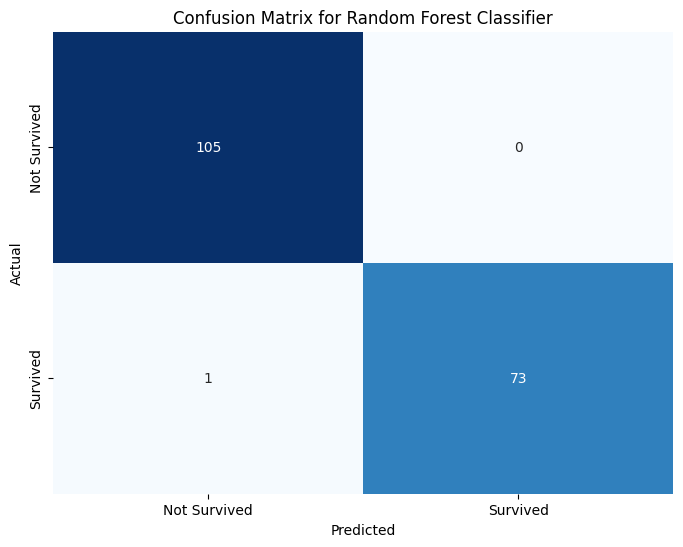

In [330]:
from sklearn.metrics import confusion_matrix

# Get confusion matrix for Random Forest Classifier
cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()